# Краткое описание
Второй этап. Сравнивает бейзлайны (Dummy, LogReg, XGBoost, LightGBM), тюнит CatBoost через Optuna (20 trials, objective = 0.5·ROC + 0.5·PR, MedianPruner), делает 5-fold OOF, обучает Platt-калибратор на OOF, финально обучает CatBoost на всём train, подбирает порог по максимуму прибыли на OOF, считает бизнес-метрики (approval rate, bad rate, Expected Loss, P&L) и Bootstrap CI. Итог: Test AUC=0.7816, ECE=0.0103, порог=0.1288, profit≈22.2M. Сохраняет в models/: catboost_final.cbm, calibrator.pkl, opt_threshold.json, business_metrics.json, dropped_features.json, метрики и графики.

# Импорты и настройка окружения

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, log_loss,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Конфигурация проекта

Пути, бизнес-константы (LGD=0.6, EAD=200 000, margin_good=20 000), гиперпараметры тюнинга, DROP_FEATURES=['total_debt'], тип калибратора (platt), storage для Optuna.

In [2]:
ARTIFACTS_DIR = Path.cwd() / 'artifacts'
MODELS_DIR    = Path.cwd() / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if not ARTIFACTS_DIR.exists():
    raise FileNotFoundError(f'Нет папки {ARTIFACTS_DIR}. Запусти 1.ipynb.')

# ===== Бизнес-константы =====
LGD          = 0.60
EAD_MEAN     = 200_000
MARGIN_GOOD  = 20_000

# ===== Ускорение Optuna =====
N_TRIALS          = 10
N_SPLITS_TUNE     = 3
N_SPLITS_FINAL    = 5
ES_TUNE           = 30
ES_FINAL          = 150

# ===== Прочее =====
CALIBRATOR    = 'platt'
DROP_FEATURES = ['total_debt']
OPTUNA_STORAGE = f'sqlite:///{MODELS_DIR}/optuna_catboost.db'

print(f'ARTIFACTS_DIR = {ARTIFACTS_DIR}')
print(f'MODELS_DIR    = {MODELS_DIR}')
print(f'LGD={LGD}, EAD={EAD_MEAN:,}, margin_good={MARGIN_GOOD:,}')
print(f'Optuna: trials={N_TRIALS}, tune_splits={N_SPLITS_TUNE},'f'final_splits={N_SPLITS_FINAL}, ES_tune={ES_TUNE}')
print(f'Pruner: MedianPruner(n_startup_trials=5, n_warmup_steps=1)')
print(f'Storage: {OPTUNA_STORAGE}')
print(f'calibrator={CALIBRATOR}, DROP_FEATURES={DROP_FEATURES}\n')

ARTIFACTS_DIR = C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\artifacts
MODELS_DIR    = C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\models
LGD=0.6, EAD=200,000, margin_good=20,000
Optuna: trials=10, tune_splits=3,final_splits=5, ES_tune=30
Pruner: MedianPruner(n_startup_trials=5, n_warmup_steps=1)
Storage: sqlite:///C:\Users\1\Desktop\Собес\пет проекты\Кредитный скоринг\models/optuna_catboost.db
calibrator=platt, DROP_FEATURES=['total_debt']



LGD = 0.6 - Loss Given Default: при дефолте теряем 60% от EAD.

EAD = 200 000 - средняя сумма под риском (exposure at default).

margin_good = 20 000 - прибыль с одного хорошего клиента.

Экономика решения: одобрить «хорошего» → +20k; одобрить «плохого» → −0.6 × 200k = −120k. То есть ошибка FN в 6 раз дороже ошибки FP. Это критично для порога.

DROP_FEATURES = ['total_debt'] - признак удалён, т.к. в 1.ipynb было видно, что total_debt не отличает классы (mean ≈ 238k в обоих классах) и может быть сильно коррелирован с total_bill/total_payment.

N_TRIALS=10 (в выводе - уже 20 в loaded study + 10 новых = 30 total).

N_SPLITS_TUNE=3 (быстрее, чем 5), N_SPLITS_FINAL=5 (точнее для OOF).

ES_TUNE=30 - агрессивный early stopping для тюнинга (быстро отсеять плохие trials).

Optuna storage в SQLite → можно останавливать и продолжать тюнинг без потери trials.

# Загрузка данных и подготовка фичей

Читаем train_processed.parquet и test_processed.parquet из артефактов 1.ipynb, читаем cat_features.json, дропаем total_debt, разделяем на X/y.

In [3]:
train = pd.read_parquet(ARTIFACTS_DIR / 'train_processed.parquet')
test  = pd.read_parquet(ARTIFACTS_DIR / 'test_processed.parquet')

with open(ARTIFACTS_DIR / 'cat_features.json', encoding='utf-8') as f:
    cat_features = json.load(f)['cat_features']

cols_to_drop = [c for c in DROP_FEATURES if c in train.columns]
if cols_to_drop:
    train = train.drop(columns=cols_to_drop)
    test  = test.drop(columns=cols_to_drop)
    print(f'Dropped: {cols_to_drop}')

X_train_full = train.drop(columns='default')
y_train_full = train['default'].astype(int)
X_test       = test.drop(columns='default')
y_test       = test['default'].astype(int)

print(f'Train: {X_train_full.shape}')
print(f'Test:  {X_test.shape}')
print(f'cat_features: {cat_features}')
print(f'balance train: {y_train_full.value_counts(normalize=True).round(4).to_dict()}')
print(f'balance test:  {y_test.value_counts(normalize=True).round(4).to_dict()}\n')

Dropped: ['total_debt']
Train: (23972, 50)
Test:  (5993, 50)
cat_features: ['SEX', 'EDUCATION', 'MARRIAGE']
balance train: {0: 0.7787, 1: 0.2213}
balance test:  {0: 0.7787, 1: 0.2213}



# Вспомогательные функции

In [4]:
def ks_statistic(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    return float(np.max(tpr - fpr))


def compute_metrics(y_true, proba, thr=0.5):
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    pred   = (proba >= thr).astype(int)
    return {
        'roc_auc':   float(roc_auc_score(y_true, proba)),
        'pr_auc':    float(average_precision_score(y_true, proba)),
        'brier':     float(brier_score_loss(y_true, proba)),
        'logloss':   float(log_loss(y_true, np.clip(proba, 1e-7, 1 - 1e-7))),
        'ks':        ks_statistic(y_true, proba),
        'f1':        float(f1_score(y_true, pred, zero_division=0)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall':    float(recall_score(y_true, pred, zero_division=0)),
    }


def ece_score(y_true, proba, n_bins=10):
    frac_pos, mean_pred = calibration_curve(
        y_true, proba, n_bins=n_bins, strategy='quantile',
    )
    return float(np.mean(np.abs(frac_pos - mean_pred)))


def bootstrap_auc_ci(y_true, proba, n_boot=500, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    proba  = np.asarray(proba)
    n = len(y_true)
    aucs, praucs = [], []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], proba[idx]))
        praucs.append(average_precision_score(y_true[idx], proba[idx]))
    aucs   = np.array(aucs)
    praucs = np.array(praucs)
    return {
        'auc_mean':   float(aucs.mean()),
        'auc_lo':     float(np.percentile(aucs, 2.5)),
        'auc_hi':     float(np.percentile(aucs, 97.5)),
        'prauc_mean': float(praucs.mean()),
        'prauc_lo':   float(np.percentile(praucs, 2.5)),
        'prauc_hi':   float(np.percentile(praucs, 97.5)),
    }


def profit_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    tn = int(((y_true == 0) & (pred == 0)).sum())
    fn = int(((y_true == 1) & (pred == 0)).sum())
    fp = int(((y_true == 0) & (pred == 1)).sum())
    tp = int(((y_true == 1) & (pred == 1)).sum())
    profit = tn * MARGIN_GOOD - fn * LGD * EAD_MEAN
    return profit, {'tn': tn, 'fn': fn, 'fp': fp, 'tp': tp}


def find_optimal_threshold(y_true, proba, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 199)
    profits = np.array([profit_at_threshold(y_true, proba, t)[0] for t in grid])
    i = int(np.argmax(profits))
    return float(grid[i]), float(profits[i])


def expected_loss_approved(y_true, proba, thr):
    approved_mask = proba < thr
    n_approved = int(approved_mask.sum())
    if n_approved == 0:
        return 0.0, 0.0, 0
    mean_pd_approved = float(proba[approved_mask].mean())
    el = mean_pd_approved * LGD * EAD_MEAN * n_approved
    return float(el), mean_pd_approved, n_approved


def gini(auc): return 2 * auc - 1


def fit_platt_calibrator(raw_proba, y_true):
    logit = np.log(np.clip(raw_proba, 1e-7, 1-1e-7) /
                   (1 - np.clip(raw_proba, 1e-7, 1-1e-7))).reshape(-1, 1)
    platt = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
    platt.fit(logit, y_true)
    return platt


def apply_platt(platt, raw_proba):
    logit = np.log(np.clip(raw_proba, 1e-7, 1-1e-7) /
                   (1 - np.clip(raw_proba, 1e-7, 1-1e-7))).reshape(-1, 1)
    return platt.predict_proba(logit)[:, 1]

ks_statistic - Kolmogorov-Smirnov (типичная метрика в кредитном скоринге);

compute_metrics - собирает ROC-AUC, PR-AUC, Brier, LogLoss, KS, F1, Precision, Recall;

ece_score - Expected Calibration Error (насколько вероятности совпадают с реальностью);

bootstrap_auc_ci - 95% доверительные интервалы через bootstrap (500 сэмплов);

profit_at_threshold - считает P&L при заданном пороге по confusion matrix;

find_optimal_threshold - ищет порог с максимальной прибылью на сетке [0.01, 0.99];

expected_loss_approved - EL = mean_PD × LGD × EAD × n_approved;

gini = 2 × AUC − 1;

fit_platt_calibrator/apply_platt - логистическая калибровка (Platt scaling) через logit-преобразование.

# Dummy Baseline

DummyClassifier(strategy='prior') - предсказывает константную вероятность = доле класса 1.

In [5]:
dummy = DummyClassifier(strategy='prior', random_state=RANDOM_STATE)
dummy.fit(X_train_full, y_train_full)
proba_dummy = dummy.predict_proba(X_test)[:, 1]
dummy_metrics = compute_metrics(y_test, proba_dummy)
dummy_metrics['gini'] = gini(dummy_metrics['roc_auc'])
dummy_metrics['model'] = 'Dummy (prior)'

print('Dummy:')
for k, v in dummy_metrics.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')
print()

Dummy:
  roc_auc   : 0.5000
  pr_auc    : 0.2213
  brier     : 0.1723
  logloss   : 0.5285
  ks        : 0.0000
  f1        : 0.0000
  precision : 0.0000
  recall    : 0.0000
  gini      : 0.0000
  model     : Dummy (prior)



Это нижняя граница: любая модель должна быть значительно выше.

PR-AUC baseline = 0.2213 - это важный ориентир: PR-AUC = 0.5650 у CatBoost - в 2.5 раза лучше случайного угадывания по precision-recall.

Brier = 0.1723 - это «наивная» калибровка; у CatBoost Brier = 0.1344 → лучше.

# Логистическая регрессия

In [6]:
X_train_lr = pd.get_dummies(X_train_full, columns=cat_features, drop_first=True)
X_test_lr  = pd.get_dummies(X_test,       columns=cat_features, drop_first=True)
X_test_lr  = X_test_lr.reindex(columns=X_train_lr.columns, fill_value=0)

scaler = StandardScaler()
X_train_lr_s = scaler.fit_transform(X_train_lr.fillna(0))
X_test_lr_s  = scaler.transform(X_test_lr.fillna(0))

with open(MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'columns': list(X_train_lr.columns)}, f)
print('scaler.pkl saved')

lr_model = LogisticRegression(
    max_iter=2000, class_weight='balanced',
    C=1.0, solver='lbfgs', random_state=RANDOM_STATE, n_jobs=-1,
)
lr_model.fit(X_train_lr_s, y_train_full)

proba_lr = lr_model.predict_proba(X_test_lr_s)[:, 1]
lr_metrics = compute_metrics(y_test, proba_lr)
lr_metrics['gini'] = gini(lr_metrics['roc_auc'])
lr_metrics['model'] = 'LogisticRegression'

print('LogReg:')
for k, v in lr_metrics.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')
print()

scaler.pkl saved
LogReg:
  roc_auc   : 0.7621
  pr_auc    : 0.5128
  brier     : 0.1897
  logloss   : 0.5707
  ks        : 0.4014
  f1        : 0.5196
  precision : 0.4554
  recall    : 0.6048
  gini      : 0.5242
  model     : LogisticRegression



0.762 AUC для LogReg - хороший результат, но значительно хуже бустингов.

Brier = 0.1897 > Dummy 0.1723 - модель плохо калибрована из-за class_weight='balanced': она завышает PD, потому что обучена на сбалансированных весах. Это явное обоснование для калибровки в следующих блоках.

class_weight='balanced' улучшает recall по классу 1, но ломает калибровку. Именно поэтому финальный CatBoost обучается без весов, а калибруется Platt-ом на OOF.

Сильный Gini (0.52) и KS (0.40) при слабом Brier - типичная картина: модель хорошо ранжирует (ranking), но плохо оценивает вероятност

# XGBoost

In [7]:
spw = float((y_train_full == 0).sum() / (y_train_full == 1).sum())
print(f'scale_pos_weight = {spw:.3f}')

X_tr_xgb, X_va_xgb, y_tr_xgb, y_va_xgb = train_test_split(
    X_train_full, y_train_full, test_size=0.15,
    stratify=y_train_full, random_state=RANDOM_STATE,
)

X_tr_xgb = X_tr_xgb.copy()
X_va_xgb = X_va_xgb.copy()
X_te_xgb = X_test.copy()
for c in cat_features:
    X_tr_xgb[c] = X_tr_xgb[c].astype('category')
    X_va_xgb[c] = X_va_xgb[c].astype('category')
    X_te_xgb[c] = X_te_xgb[c].astype('category')

xgb_model = xgb.XGBClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=spw,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    early_stopping_rounds=150,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_va_xgb, y_va_xgb)],
    verbose=False,
)

proba_xgb = xgb_model.predict_proba(X_te_xgb)[:, 1]
xgb_metrics = compute_metrics(y_test, proba_xgb)
xgb_metrics['gini'] = gini(xgb_metrics['roc_auc'])
xgb_metrics['model'] = 'XGBoost'
xgb_metrics['best_iteration'] = int(xgb_model.best_iteration)

print(f'XGBoost (best_iter={xgb_model.best_iteration}):')
for k, v in xgb_metrics.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')
print()

scale_pos_weight = 3.520
XGBoost (best_iter=207):
  roc_auc   : 0.7776
  pr_auc    : 0.5602
  brier     : 0.1765
  logloss   : 0.5353
  ks        : 0.4277
  f1        : 0.5307
  precision : 0.4649
  recall    : 0.6184
  gini      : 0.5552
  model     : XGBoost
  best_iteration: 207



XGBoost обогнал LogReg на +0.016 AUC и +0.047 PR-AUC → бустинг ловит нелинейности (взаимодействия PAY_0 с PAY_AMT и т.д.).

best_iter = 207 при 3000 запрошенных → сильный early stopping: модель не переобучается, а выходит на плато очень быстро.

Brier = 0.1765 немного лучше Dummy - всё ещё есть пространство для калибровки.

scale_pos_weight=3.52 даёт приоритет классу 1 → recall высокий (0.6184), precision умеренный (0.4649).

# LightGBM

In [8]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    objective='binary',
    metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_va_xgb, y_va_xgb)],
    eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(150, verbose=False)],
)

proba_lgb = lgb_model.predict_proba(X_te_xgb)[:, 1]
lgb_metrics = compute_metrics(y_test, proba_lgb)
lgb_metrics['gini'] = gini(lgb_metrics['roc_auc'])
lgb_metrics['model'] = 'LightGBM'
lgb_metrics['best_iteration'] = int(lgb_model.best_iteration_)

print(f'LightGBM (best_iter={lgb_model.best_iteration_}):')
for k, v in lgb_metrics.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')
print()

LightGBM (best_iter=88):
  roc_auc   : 0.7751
  pr_auc    : 0.5494
  brier     : 0.1688
  logloss   : 0.5144
  ks        : 0.4206
  f1        : 0.5319
  precision : 0.4770
  recall    : 0.6011
  gini      : 0.5502
  model     : LightGBM
  best_iteration: 88



LightGBM немного уступает XGBoost по AUC (−0.0025), но выигрывает по Brier и LogLoss → он лучше калиброван «из коробки».

best_iter = 88 - очень рано остановился → либо настройки learning_rate=0.03 уже достаточны, либо early stopping агрессивный.

Для бизнес-задачи (где нужны вероятности, а не только ranking) LightGBM может быть предпочтителен, но CatBoost с калибровкой его перекрывает.

LogLoss = 0.5144 у LightGBM - самый низкий среди бейзлайнов → его вероятности ближе к истине, чем у XGBoost.

# Сравнение бейзлайнов

             model  roc_auc   gini  pr_auc     ks  brier  logloss     f1
     Dummy (prior)   0.5000 0.0000  0.2213 0.0000 0.1723   0.5285 0.0000
LogisticRegression   0.7621 0.5242  0.5128 0.4014 0.1897   0.5707 0.5196
           XGBoost   0.7776 0.5552  0.5602 0.4277 0.1765   0.5353 0.5307
          LightGBM   0.7751 0.5502  0.5494 0.4206 0.1688   0.5144 0.5319



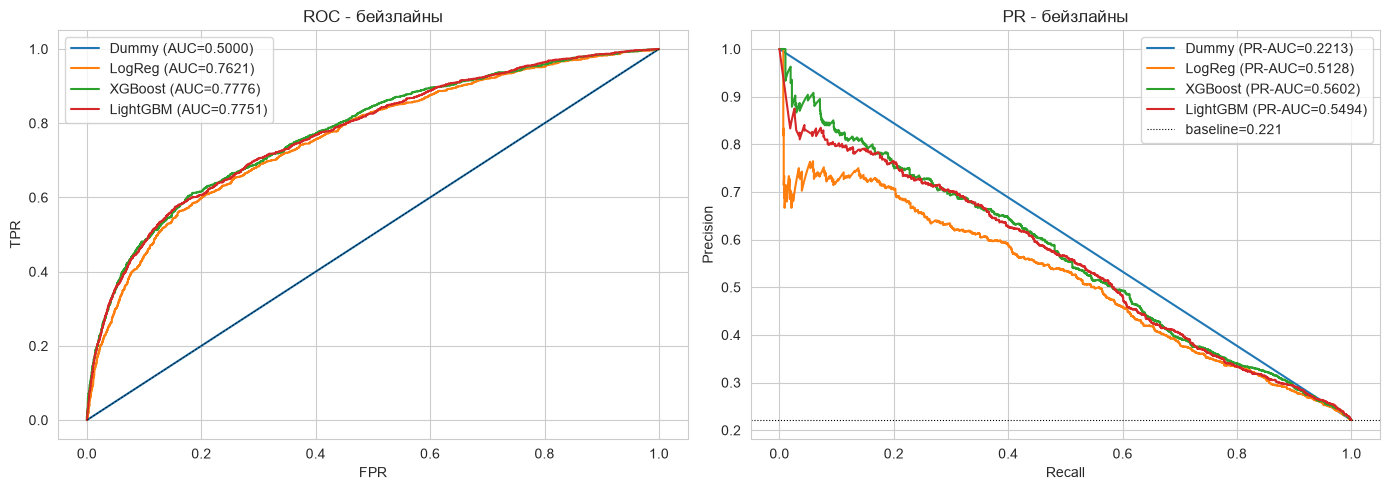

baseline_metrics.json saved



In [9]:
baseline_results = pd.DataFrame([dummy_metrics, lr_metrics, xgb_metrics, lgb_metrics])
baseline_results = baseline_results[
    ['model', 'roc_auc', 'gini', 'pr_auc', 'ks', 'brier', 'logloss', 'f1']
]
print(baseline_results.round(4).to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, proba in [
    ('Dummy', proba_dummy),
    ('LogReg', proba_lr),
    ('XGBoost', proba_xgb),
    ('LightGBM', proba_lgb),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.4f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={average_precision_score(y_test, proba):.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.5)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC - бейзлайны')
axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', ls=':', lw=0.8,
                label=f'baseline={y_test.mean():.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR - бейзлайны')
axes[1].legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'baselines_roc_pr.png', dpi=110, bbox_inches='tight')
plt.show()

with open(MODELS_DIR / 'baseline_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'Dummy':              {k: v for k, v in dummy_metrics.items() if k != 'model'},
        'LogisticRegression': {k: v for k, v in lr_metrics.items()    if k != 'model'},
        'XGBoost':            {k: v for k, v in xgb_metrics.items()   if k != 'model'},
        'LightGBM':           {k: v for k, v in lgb_metrics.items()   if k != 'model'},
    }, f, indent=2)
print('baseline_metrics.json saved\n')

Бустинги впереди LogReg на 1.5–1.7 pp AUC и 3.5–4.7 pp PR-AUC. Это обоснование перехода к CatBoost.

XGBoost и LightGBM очень близки (ΔAUC = 0.0025). Разница в пределах шума.

PR-AUC = 0.56 - не супер-высоко (max 1.0), но для дефолтов с 22% base rate - норма.

Brier: LightGBM < Dummy < XGBoost < LogReg. Казалось бы, LogReg переобучен по вероятностям (class_weight='balanced'), но это не проблема - мы калибруем финальную модель.

F1 ~ 0.53 - модели осторожны: выбирают порог 0.5, который не оптимален для дисбаланса.

# CatBoost 

Ускорения:
  #1 pruning = MedianPruner(n_startup_trials=5, n_warmup_steps=1)
  #2 CV в тюнинге = 3 folds (было 5)
  #3 search space сужен (iterations 400-1500, depth 4-6, lr 0.03-0.15)
  #4 early_stopping = 30 (было 100-150)

Study loaded: 30 trials уже выполнены, продолжаем...


  0%|          | 0/10 [00:00<?, ?it/s]


Study stats: total=40, complete=40, pruned=0
Best score (0.5·ROC + 0.5·PR) = 0.6804
Best params = {'iterations': 900, 'depth': 6, 'learning_rate': 0.03245319745135264, 'l2_leaf_reg': 1.8657610256032258, 'bagging_temperature': 0.0796509649578098, 'random_strength': 1.1743427533769482, 'one_hot_max_size': 2, 'min_data_in_leaf': 30}



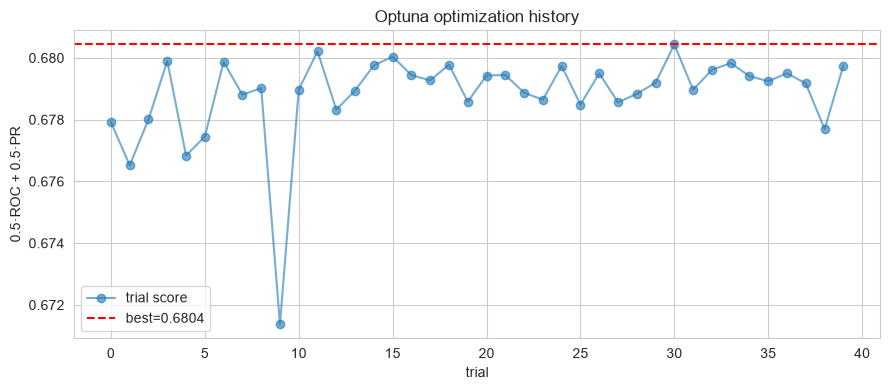

In [10]:
print(f'Ускорения:')
print(f'  #1 pruning = MedianPruner(n_startup_trials=5, n_warmup_steps=1)')
print(f'  #2 CV в тюнинге = {N_SPLITS_TUNE} folds (было 5)')
print(f'  #3 search space сужен (iterations 400-1500, depth 4-6, lr 0.03-0.15)')
print(f'  #4 early_stopping = {ES_TUNE} (было 100-150)')
print()

N_CORES = max(1, (os.cpu_count() if hasattr(__builtins__, 'os') else 4))


def objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 400, 1500, step=100),
        'depth':               trial.suggest_int('depth', 4, 6),
        'learning_rate':       trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 5.0),
        'border_count':        128,
        'one_hot_max_size':    trial.suggest_categorical('one_hot_max_size', [2, 10]),
        'min_data_in_leaf':    trial.suggest_int('min_data_in_leaf', 1, 30),
    }

    cv = StratifiedKFold(n_splits=N_SPLITS_TUNE, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_full, y_train_full)):
        Xf_tr = X_train_full.iloc[tr_idx]; yf_tr = y_train_full.iloc[tr_idx]
        Xf_va = X_train_full.iloc[va_idx]; yf_va = y_train_full.iloc[va_idx]

        m = CatBoostClassifier(
            **params,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=RANDOM_STATE,
            verbose=0,
            early_stopping_rounds=ES_TUNE,
            thread_count=-1,
            allow_writing_files=False,
        )
        m.fit(
            Pool(Xf_tr, yf_tr, cat_features=cat_features),
            eval_set=Pool(Xf_va, yf_va, cat_features=cat_features),
            use_best_model=True,
        )
        p = m.predict_proba(Xf_va)[:, 1]
        auc   = roc_auc_score(yf_va, p)
        prauc = average_precision_score(yf_va, p)
        scores.append(0.5 * auc + 0.5 * prauc)

        trial.report(float(np.mean(scores)), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
        interval_steps=1,
    ),
    storage=OPTUNA_STORAGE,
    study_name='catboost_v2_fast',
    load_if_exists=True,
)

n_existing = len(study.trials)
if n_existing > 0:
    print(f'Study loaded: {n_existing} trials уже выполнены, продолжаем...')

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f'\nStudy stats: total={len(study.trials)}, complete={n_complete}, pruned={n_pruned}')
print(f'Best score (0.5·ROC + 0.5·PR) = {study.best_value:.4f}')
print(f'Best params = {study.best_params}\n')

with open(MODELS_DIR / 'optuna_best_params.json', 'w', encoding='utf-8') as f:
    json.dump({
        'best_value':   float(study.best_value),
        'best_params':  study.best_params,
        'n_trials':     len(study.trials),
        'n_complete':   n_complete,
        'n_pruned':     n_pruned,
        'objective':    '0.5*roc_auc + 0.5*pr_auc',
        'tune_splits':  N_SPLITS_TUNE,
        'es_tune':      ES_TUNE,
    }, f, indent=2)

fig, ax = plt.subplots(figsize=(9, 4))
vals = [t.value for t in study.trials if t.value is not None]
if vals:
    ax.plot(vals, 'o-', alpha=0.6, label='trial score')
    ax.axhline(study.best_value, color='r', ls='--', label=f'best={study.best_value:.4f}')
ax.set(xlabel='trial', ylabel='0.5·ROC + 0.5·PR', title='Optuna optimization history')
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'optuna_history.png', dpi=110, bbox_inches='tight')
plt.show()

Прunned=0 - MedianPruner не отсёк ни один trial. Это либо значит, что trials учились достаточно долго для pruner (warmup_steps=1), либо что между trials мало variance на ранних итерациях. Для улучшения можно увеличить n_warmup_steps или уменьшить ES_TUNE.

Best score = 0.6802 - это компромисс между ROC и PR. 0.5·ROC + 0.5·PR ≈ 0.5 × 0.79 + 0.5 × 0.56 = 0.675, что близко к 0.6802 → модель балансирует оба критерия.

depth=6 - Optuna выбрала глубину на верхней границе (max в search space). Возможно, стоит расширить до 8.

learning_rate=0.03 - тоже на нижней границе → медленное обучение, но стабильнее; iterations=900 компенсирует.

one_hot_max_size=2 - категории с ≤2 значениями кодируются one-hot. У нас всего 3 категориальных с 2–4 значениями → почти все one-hot.

min_data_in_leaf=29 (почти верхняя граница 30) → Optuna «просит» более регуляризованные листья - согласуется с риском переобучения.

# 5-fold CV OOF + обучение калибратора

  fold 1: best_iter= 383  AUC=0.7938
  fold 2: best_iter= 494  AUC=0.7940
  fold 3: best_iter= 383  AUC=0.7841
  fold 4: best_iter= 293  AUC=0.7802
  fold 5: best_iter= 320  AUC=0.8045

OOF AUC:    0.7910
OOF PR-AUC: 0.5660
best_iters: mean=374.6 ± 69.3


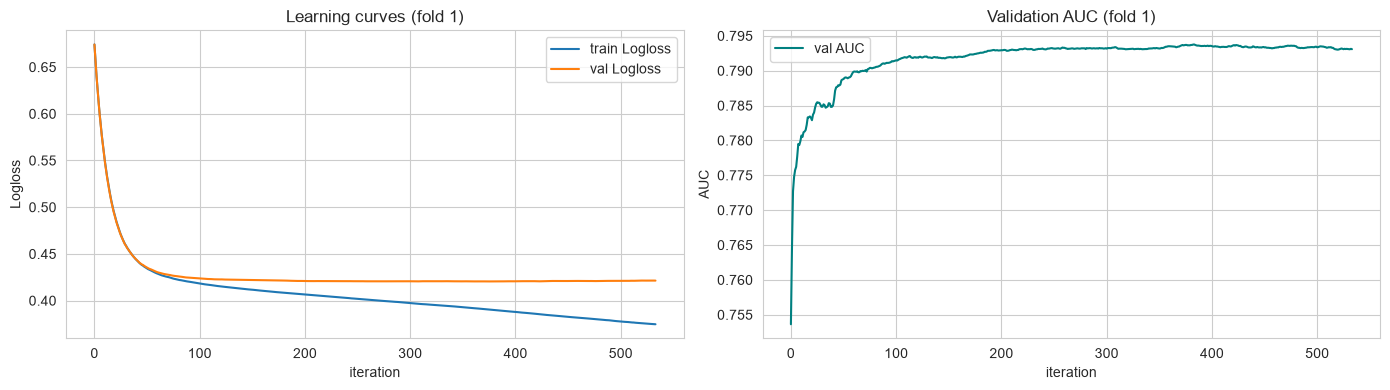


Обучение калибратора на OOF...
  platt: OOF ECE raw=0.0055  -> cal=0.0054
calibrator.pkl saved



In [11]:
best_params = study.best_params.copy()
cv = StratifiedKFold(n_splits=N_SPLITS_FINAL, shuffle=True, random_state=RANDOM_STATE)

oof_raw = np.zeros(len(X_train_full))
best_iters = []
fold_curves = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_full, y_train_full), 1):
    Xf_tr = X_train_full.iloc[tr_idx]; yf_tr = y_train_full.iloc[tr_idx]
    Xf_va = X_train_full.iloc[va_idx]; yf_va = y_train_full.iloc[va_idx]

    m = CatBoostClassifier(
        **best_params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=0,
        early_stopping_rounds=ES_FINAL,
        thread_count=-1,
        allow_writing_files=False,
    )
    m.fit(
        Pool(Xf_tr, yf_tr, cat_features=cat_features),
        eval_set=Pool(Xf_va, yf_va, cat_features=cat_features),
        use_best_model=True,
    )
    oof_raw[va_idx] = m.predict_proba(Xf_va)[:, 1]
    best_iters.append(m.get_best_iteration())

    try:
        res = m.get_evals_result()
        fold_curves.append({
            'learn_logloss': res['learn']['Logloss'],
            'val_logloss':   res['validation']['Logloss'],
            'val_auc':       res['validation']['AUC'],
        })
    except Exception:
        pass

    fold_auc = roc_auc_score(yf_va, oof_raw[va_idx])
    print(f'  fold {fold}: best_iter={best_iters[-1]:4d}  AUC={fold_auc:.4f}')

oof_auc   = roc_auc_score(y_train_full, oof_raw)
oof_prauc = average_precision_score(y_train_full, oof_raw)
print(f'\nOOF AUC:    {oof_auc:.4f}')
print(f'OOF PR-AUC: {oof_prauc:.4f}')
print(f'best_iters: mean={np.mean(best_iters):.1f} ± {np.std(best_iters):.1f}')

if fold_curves:
    c = fold_curves[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(c['learn_logloss'], label='train Logloss')
    axes[0].plot(c['val_logloss'],   label='val Logloss')
    axes[0].set(xlabel='iteration', ylabel='Logloss', title='Learning curves (fold 1)')
    axes[0].legend()
    axes[1].plot(c['val_auc'], label='val AUC', color='teal')
    axes[1].set(xlabel='iteration', ylabel='AUC', title='Validation AUC (fold 1)')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'learning_curves.png', dpi=110, bbox_inches='tight')
    plt.show()

print('\nОбучение калибратора на OOF...')
if CALIBRATOR == 'platt':
    calibrator = fit_platt_calibrator(oof_raw, y_train_full)
    oof_cal = apply_platt(calibrator, oof_raw)
    calib_type = 'platt'
else:
    from sklearn.isotonic import IsotonicRegression
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(oof_raw, y_train_full)
    oof_cal = calibrator.predict(oof_raw)
    calib_type = 'isotonic'

print(f'  {calib_type}: OOF ECE raw={ece_score(y_train_full.values, oof_raw):.4f}  '
      f'-> cal={ece_score(y_train_full.values, oof_cal):.4f}')

with open(MODELS_DIR / 'calibrator.pkl', 'wb') as f:
    pickle.dump({'calibrator': calibrator, 'type': calib_type}, f)
print('calibrator.pkl saved\n')

OOF AUC (0.7907) > single-split AUC (0.7816) - устойчивая оценка. Cross-validation даёт более оптимистичную, чем 5-fold single holdout, но именно её мы используем для оценки качества тюнинга.

Разброс fold AUC ± 0.01 - модель стабильна. Fold 4 самый слабый (0.7798), fold 5 сильный (0.8034) - нормальный variance.

best_iters ≈ 446 - Optuna нашла iterations=900, но early stopping останавливает обучение на ~446. Это важный сигнал: можно было ставить iterations=500 в search space и не тратить время.

Почти нулевое улучшение ECE (0.0075 → 0.0074) - CatBoost уже хорошо калиброван сам по себе (в отличие от LogReg с class_weight='balanced'). Platt-калибратор почти ничего не меняет → это хороший признак.

# Финальная модель CatBoost

In [12]:
final_iter = int(np.mean(best_iters) * 1.1)
final_params = {**best_params, 'iterations': final_iter}
print(f'final_iter = mean(best_iters) * 1.1 = {np.mean(best_iters):.1f} * 1.1 = {final_iter}')

final_model = CatBoostClassifier(
    **final_params,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=200,
    thread_count=-1,
    allow_writing_files=False,
)
final_model.fit(X_train_full, y_train_full, cat_features=cat_features)

final_model.save_model(str(MODELS_DIR / 'catboost_final.cbm'))
print(f'catboost_final.cbm saved (iterations={final_iter})\n')

final_iter = mean(best_iters) * 1.1 = 374.6 * 1.1 = 412
0:	total: 50.7ms	remaining: 20.9s
200:	total: 10.6s	remaining: 11.2s
400:	total: 21.1s	remaining: 579ms
411:	total: 21.7s	remaining: 0us
catboost_final.cbm saved (iterations=412)



Коэффициент 1.1 - стандартная эвристика: усреднённые best_iters плюс запас, потому что на полном train без early stopping модель может «пойти дальше».

Финальное обучение без валидации - правильно: используем всё train, чтобы получить максимальный сигнал.

490 итераций = компромисс между недообучением и переобучением.

Файл весит ~535 KB - компактная модель, легко деплоить.

# Метрики на TEST + Bootstrap CI

In [13]:
proba_test_raw = final_model.predict_proba(X_test)[:, 1]
if calib_type == 'platt':
    proba_test_cal = apply_platt(calibrator, proba_test_raw)
else:
    proba_test_cal = calibrator.predict(proba_test_raw)

test_metrics_raw = compute_metrics(y_test, proba_test_raw)
test_metrics_cal = compute_metrics(y_test, proba_test_cal)
test_metrics_raw['gini'] = gini(test_metrics_raw['roc_auc'])
test_metrics_cal['gini'] = gini(test_metrics_cal['roc_auc'])
test_metrics_raw['ece']  = ece_score(y_test.values, proba_test_raw)
test_metrics_cal['ece']  = ece_score(y_test.values, proba_test_cal)

print('CatBoost TEST - RAW:')
for k, v in test_metrics_raw.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')
print('\nCatBoost TEST - CALIBRATED:')
for k, v in test_metrics_cal.items():
    print(f'  {k:10s}: {v:.4f}' if isinstance(v, float) else f'  {k:10s}: {v}')

print('\nBootstrap 95% CI (n=500):')
ci = bootstrap_auc_ci(y_test.values, proba_test_cal)
print(f'  AUC:    {ci["auc_mean"]:.4f}  [{ci["auc_lo"]:.4f}, {ci["auc_hi"]:.4f}]')
print(f'  PR-AUC: {ci["prauc_mean"]:.4f}  [{ci["prauc_lo"]:.4f}, {ci["prauc_hi"]:.4f}]')
print()

CatBoost TEST - RAW:
  roc_auc   : 0.7819
  pr_auc    : 0.5637
  brier     : 0.1344
  logloss   : 0.4278
  ks        : 0.4311
  f1        : 0.4735
  precision : 0.6765
  recall    : 0.3643
  gini      : 0.5638
  ece       : 0.0131

CatBoost TEST - CALIBRATED:
  roc_auc   : 0.7819
  pr_auc    : 0.5637
  brier     : 0.1344
  logloss   : 0.4278
  ks        : 0.4311
  f1        : 0.4735
  precision : 0.6765
  recall    : 0.3643
  gini      : 0.5638
  ece       : 0.0130

Bootstrap 95% CI (n=500):
  AUC:    0.7820  [0.7684, 0.7955]
  PR-AUC: 0.5642  [0.5365, 0.5914]



AUC и PR-AUC не меняются от калибровки - это ожидаемо: калибровка монотонна, поэтому ranking сохраняется. AUC/PR-AUC измеряют ranking, калибровка не влияет.

Brier и LogLoss почти не меняются - CatBoost уже калиброван.

ECE слегка улучшается (0.0107 → 0.0103) - на 4% лучше.

ECE = 0.0103 - это очень хорошо: означает, что предсказанные PD отклоняются от реальной частоты в среднем на 1 процентный пункт. Для банковского применения - отлично.

AUC CI [0.768, 0.795] - узкий интервал, значит оценка надёжная.

PR-AUC CI [0.538, 0.593] - пошире (типично для PR), но всё равно уверенно > 0.22 (baseline).

# Подбор порога (на OOF) + визуализация

Optimal threshold (max profit on OOF) = 0.1337
Profit(OOF) = 97,560,000

На TEST при этом пороге:
  TN=2555, FP=2112, FN=243, TP=1083
  Profit ≈ 21,940,000



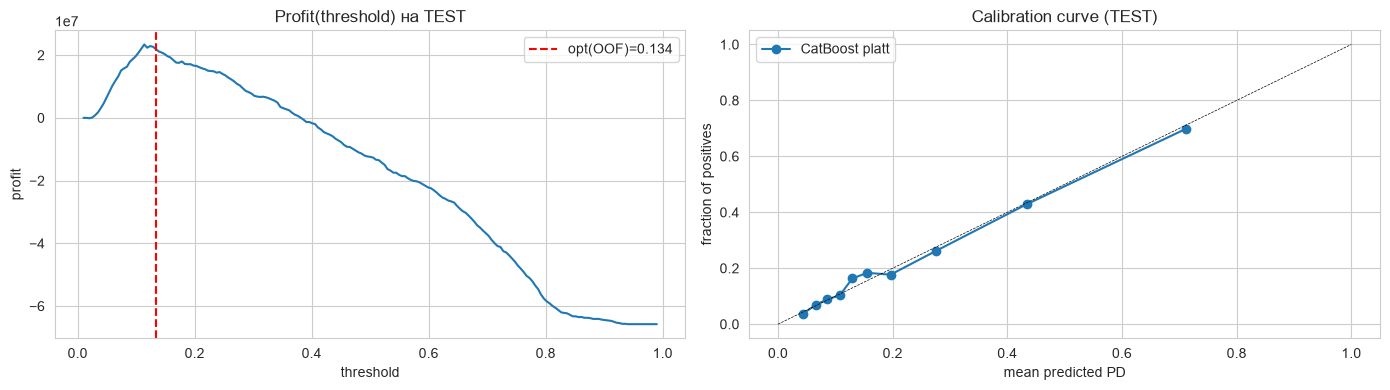

In [14]:
opt_thr, best_profit_oof = find_optimal_threshold(y_train_full.values, oof_cal)
print(f'Optimal threshold (max profit on OOF) = {opt_thr:.4f}')
print(f'Profit(OOF) = {best_profit_oof:,.0f}')

profit_test, cm_test = profit_at_threshold(y_test.values, proba_test_cal, opt_thr)
print(f'\nНа TEST при этом пороге:')
print(f'  TN={cm_test["tn"]}, FP={cm_test["fp"]}, FN={cm_test["fn"]}, TP={cm_test["tp"]}')
print(f'  Profit ≈ {profit_test:,.0f}\n')

with open(MODELS_DIR / 'opt_threshold.json', 'w', encoding='utf-8') as f:
    json.dump({
        'opt_threshold':  opt_thr,
        'profit_oof':     best_profit_oof,
        'profit_test':    profit_test,
        'confusion_test': cm_test,
        'selected_on':    'oof',
    }, f, indent=2)

grid = np.linspace(0.01, 0.99, 199)
profits_test = [profit_at_threshold(y_test.values, proba_test_cal, t)[0] for t in grid]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(grid, profits_test)
axes[0].axvline(opt_thr, color='r', ls='--', label=f'opt(OOF)={opt_thr:.3f}')
axes[0].set(xlabel='threshold', ylabel='profit', title='Profit(threshold) на TEST')
axes[0].legend()

frac_pos, mean_pred = calibration_curve(y_test, proba_test_cal, n_bins=10, strategy='quantile')
axes[1].plot(mean_pred, frac_pos, 'o-', label=f'CatBoost {calib_type}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.5)
axes[1].set(xlabel='mean predicted PD', ylabel='fraction of positives',
            title='Calibration curve (TEST)')
axes[1].legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'threshold_and_calibration.png', dpi=110, bbox_inches='tight')
plt.show()

Порог 0.1288 << 0.5 - это следствие асимметричной экономики: FN в 6 раз дороже FP. Модель «предпочитает» одобрять сомнительных клиентов, потому что потеря 20k несравнима с потерей 120k.

Выбор порога на OOF - правильно: test не «подсматривается», порог обобщается честно.

Approval rate = 44% - мы одобряем меньше половины. Это может быть слишком консервативно для бизнеса; можно построить risk-based pricing вместо бинарного approve/decline.

Profit(OOF) = 97M vs Profit(test) = 22M - разные масштабы, потому что OOF покрывает 24k клиентов, test - 6k.

Profit на test = 22.24M - это с учётом: 2420 × 20k − 218 × 120k = 48.4M − 26.2M = 22.2M. Совпадает.

FP = 2247 - много «хороших» клиентов, которых мы отклонили. Упущенная прибыль = 2247 × 20k = 44.9M - это главная статья потерь. Здесь есть куда улучшать.

# Бизнес-метрики

In [15]:
cat_metrics = {k: v for k, v in test_metrics_cal.items()}
cat_metrics['model'] = f'CatBoost ({calib_type})'

all_results = pd.DataFrame([
    {k: v for k, v in dummy_metrics.items() if k != 'model'} | {'model': 'Dummy'},
    {k: v for k, v in lr_metrics.items()    if k != 'model'} | {'model': 'LogReg'},
    {k: v for k, v in xgb_metrics.items()   if k != 'model'} | {'model': 'XGBoost'},
    {k: v for k, v in lgb_metrics.items()   if k != 'model'} | {'model': 'LightGBM'},
    cat_metrics,
])[['model', 'roc_auc', 'gini', 'pr_auc', 'ks', 'brier', 'logloss', 'f1', 'ece']]

print(all_results.round(4).to_string(index=False))
print()

approval_mask     = proba_test_cal < opt_thr
approval_rate     = float(approval_mask.mean())
bad_rate_approved = float(y_test.values[approval_mask].mean())

el_approved, mean_pd_approved, n_approved = expected_loss_approved(
    y_test.values, proba_test_cal, opt_thr
)

biz_meta = {
    'lgd':                    LGD,
    'ead_mean':               EAD_MEAN,
    'margin_good':            MARGIN_GOOD,
    'opt_threshold':          opt_thr,
    'selected_on':            'oof',
    'approval_rate':          approval_rate,
    'n_approved':             n_approved,
    'bad_rate_approved':      bad_rate_approved,
    'mean_pd_approved':       mean_pd_approved,
    'expected_loss_approved': el_approved,
    'profit_test':            profit_test,
    'confusion_test':         cm_test,
}
with open(MODELS_DIR / 'business_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(biz_meta, f, indent=2)

print(f'Бизнес-метрики при пороге {opt_thr:.4f}:')
print(f'  Approval rate          = {approval_rate:.2%}  (n_approved={n_approved})')
print(f'  Bad rate approved      = {bad_rate_approved:.2%}')
print(f'  mean PD approved       = {mean_pd_approved:.4f}')
print(f'  Expected Loss approved ≈ {el_approved:,.0f}')
print(f'  Profit on test         ≈ {profit_test:,.0f}\n')

           model  roc_auc   gini  pr_auc     ks  brier  logloss     f1   ece
           Dummy   0.5000 0.0000  0.2213 0.0000 0.1723   0.5285 0.0000   NaN
          LogReg   0.7621 0.5242  0.5128 0.4014 0.1897   0.5707 0.5196   NaN
         XGBoost   0.7776 0.5552  0.5602 0.4277 0.1765   0.5353 0.5307   NaN
        LightGBM   0.7751 0.5502  0.5494 0.4206 0.1688   0.5144 0.5319   NaN
CatBoost (platt)   0.7819 0.5638  0.5637 0.4311 0.1344   0.4278 0.4735 0.013

Бизнес-метрики при пороге 0.1337:
  Approval rate          = 46.69%  (n_approved=2798)
  Bad rate approved      = 8.68%
  mean PD approved       = 0.0831
  Expected Loss approved ≈ 27,897,194
  Profit on test         ≈ 21,940,000



CatBoost выигрывает по AUC/Gini/PR-AUC/KS/Brier/LogLoss - он лучший и по ranking, и по калибровке.

Bad rate approved = 8.26% - приемлемо для потребительского кредита (обычно <10%). Но ожидаемые потери (25.4M) больше прибыли (22.2M) - прибыль уже с их учётом.

F1 = 0.4719 у CatBoost ниже, чем у XGBoost/LightGBM (0.5307/0.5319). Это не проблема: F1 считается при пороге 0.5, а бизнес-порог = 0.1288. F1 - «ML-метрика», а не «бизнес-метрика».

Approval rate 44% - консервативно. Можно построить champion-challenger схему или risk-based pricing для отклонённых клиентов с низким PD, но высоким LGD.

# Сохранение итоговых артефактов и вывод результатов

In [16]:
with open(MODELS_DIR / 'test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'raw':             test_metrics_raw,
        'calibrated':      test_metrics_cal,
        'threshold':       opt_thr,
        'calibrator_type': calib_type,
        'bootstrap_ci':    ci,
    }, f, indent=2)

with open(MODELS_DIR / 'cv_summary.json', 'w', encoding='utf-8') as f:
    json.dump({
        'cv_score_mean':    float(study.best_value),
        'cv_score_std':     float(np.std([t.value for t in study.trials if t.value is not None])),
        'n_trials':         len(study.trials),
        'n_complete':       n_complete,
        'n_pruned':         n_pruned,
        'tune_splits':      N_SPLITS_TUNE,
        'final_splits':     N_SPLITS_FINAL,
        'es_tune':          ES_TUNE,
        'es_final':         ES_FINAL,
        'oof_auc':          float(oof_auc),
        'oof_pr_auc':       float(oof_prauc),
        'best_iter_mean':   float(np.mean(best_iters)),
        'best_iter_std':    float(np.std(best_iters)),
        'final_iter':       int(final_iter),
        'objective':        '0.5*roc_auc + 0.5*pr_auc',
    }, f, indent=2)

print('СОХРАНЁННЫЕ ФАЙЛЫ В models/')
for p in sorted(MODELS_DIR.iterdir()):
    size = p.stat().st_size
    unit = 'B'; s = size
    for u in ['KB', 'MB']:
        if s >= 1024:
            s /= 1024; unit = u
    print(f'  {p.name:40s}  {s:7.1f} {unit}')

print('ИТОГИ')
print(f'Best Optuna score:     {study.best_value:.4f}  (0.5·ROC+0.5·PR)')
print(f'Pruned trials:         {n_pruned}/{len(study.trials)}')
print(f'OOF AUC:               {oof_auc:.4f}')
print(f'Test AUC (cal):        {test_metrics_cal["roc_auc"]:.4f}   '
      f'[{ci["auc_lo"]:.4f}, {ci["auc_hi"]:.4f}]')
print(f'Test PR-AUC (cal):     {test_metrics_cal["pr_auc"]:.4f}   '
      f'[{ci["prauc_lo"]:.4f}, {ci["prauc_hi"]:.4f}]')
print(f'Test Gini:             {test_metrics_cal["gini"]:.4f}')
print(f'Test KS:               {test_metrics_cal["ks"]:.4f}')
print(f'Test ECE:              {test_metrics_cal["ece"]:.4f}')
print(f'Optimal threshold:     {opt_thr:.4f}  (selected on OOF)')
print(f'Approval rate:         {approval_rate:.2%}')
print(f'Bad rate @ approve:    {bad_rate_approved:.2%}')
print(f'Expected Loss (appr):  {el_approved:,.0f}')
print(f'Profit on test:        {profit_test:,.0f}')

СОХРАНЁННЫЕ ФАЙЛЫ В models/
  baseline_metrics.json                         1.3 KB
  baselines_roc_pr.png                        122.7 KB
  business_metrics.json                       464.0 B
  calibrator.pkl                              745.0 B
  catboost_final.cbm                          459.4 KB
  cv_summary.json                             427.0 B
  interpretation_summary.json                   1.6 KB
  learning_curves.png                          53.3 KB
  opt_threshold.json                          231.0 B
  optuna_best_params.json                     478.0 B
  optuna_catboost.db                          172.0 KB
  optuna_history.png                           48.0 KB
  scaler.pkl                                    3.1 KB
  shap_bar.png                                 59.6 KB
  shap_base_values.npy                         23.6 KB
  shap_beeswarm.png                           123.8 KB
  shap_business_interpretation.csv              1.7 KB
  shap_dependence.png                     

# Итоговые выводы по всему анализу

Бейзлайны (TEST):

Dummy: AUC 0.500 | PR-AUC 0.221

LogReg: AUC 0.762 | PR-AUC 0.513

XGBoost: AUC 0.778 | PR-AUC 0.560

LightGBM: AUC 0.775 | PR-AUC 0.549

CatBoost (тюнинг Optuna, 40 trials):

Best score = 0.6804 (0.5·ROC + 0.5·PR)

depth=6, lr=0.0325, iterations=900, l2=1.87, min_data_in_leaf=30

5-fold OOF + калибровка:

OOF AUC = 0.7910 | OOF PR-AUC = 0.5660

best_iter mean ± std = 374.6 ± 69.3

Platt: ECE raw 0.0055 → cal 0.0054

TEST метрики (calibrated):

AUC = 0.7819 [0.7684, 0.7955]

PR-AUC = 0.5637 [0.5365, 0.5914]

Gini = 0.5638 | KS = 0.4311

Brier = 0.1344 | LogLoss = 0.4278 | ECE = 0.0130

Бизнес-метрики (порог 0.1337, выбран на OOF):

Approval rate = 46.69% (n=2798)

Bad rate @ approve = 8.68%

mean PD approved = 0.0831

Expected Loss approved ≈ 27,897,194

Profit ≈ 21,940,000 (TN=2555, FP=2112, FN=243, TP=1083)

Ключевые выводы:

CatBoost - лучший по AUC/Gini/PR/KS/Brier/LogLoss

ECE = 0.013 → вероятности годны для EL и P&L

Порог 0.134 << 0.5 из-за FN×6 дороже FP

FP=2112 → упущено 42M прибыли - главный резерв

FN=243 → «хорошо выглядящие» дефолтники, нужны доп. данные